In [133]:
import pandas as pd
import numpy as np
import matplotlib as plt
import matplotlib.pyplot as plt
from scipy.special import inv_boxcox
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer

In [134]:
df = pd.read_csv("C:/Users/Ralph Arren/Desktop/Uni/Uni Year 3/ML_project/engineered_nyc_2.csv")
df.head()

,Fiscal_Year,Borough,Award,Council_District_num,Sector,Category
0,2019,X,250000,16.0,Housing & Dev,Community/Housing
1,2019,K,3640000,37.0,Health & Human Svcs,"Education, Infrastructure/Renovation"
2,2019,M,425000,5.0,Education,"Education, Infrastructure/Renovation"
3,2019,M,100000,5.0,Education,"Education, Infrastructure/Renovation, Parks & ..."
4,2019,M,35000,5.0,Education,"Education, Infrastructure/Renovation, Technology"


In [135]:
df.isna().sum()

Fiscal_Year              0
Borough                  0
Award                    0
Council_District_num    26
Sector                   0
Category                 0
dtype: int64

In [136]:
df["Council_District_num"] = df["Council_District_num"].fillna("No_District")
#check
df.isna().sum()

Fiscal_Year             0
Borough                 0
Award                   0
Council_District_num    0
Sector                  0
Category                0
dtype: int64

In [137]:
print(df['Award'].max())
print(df['Award'].min())
print(df['Award'].mean())
print(df['Award'].median())

15800000
10000
530864.850752763
172000.0


In [138]:
pt = PowerTransformer(method='yeo-johnson')
df['transformed_Awards'] = pt.fit_transform(df[['Award']])
df.head()

,Fiscal_Year,Borough,Award,Council_District_num,Sector,Category,transformed_Awards
0,2019,X,250000,16.0,Housing & Dev,Community/Housing,0.319921
1,2019,K,3640000,37.0,Health & Human Svcs,"Education, Infrastructure/Renovation",1.878587
2,2019,M,425000,5.0,Education,"Education, Infrastructure/Renovation",0.728904
3,2019,M,100000,5.0,Education,"Education, Infrastructure/Renovation, Parks & ...",-0.548346
4,2019,M,35000,5.0,Education,"Education, Infrastructure/Renovation, Technology",-1.863294


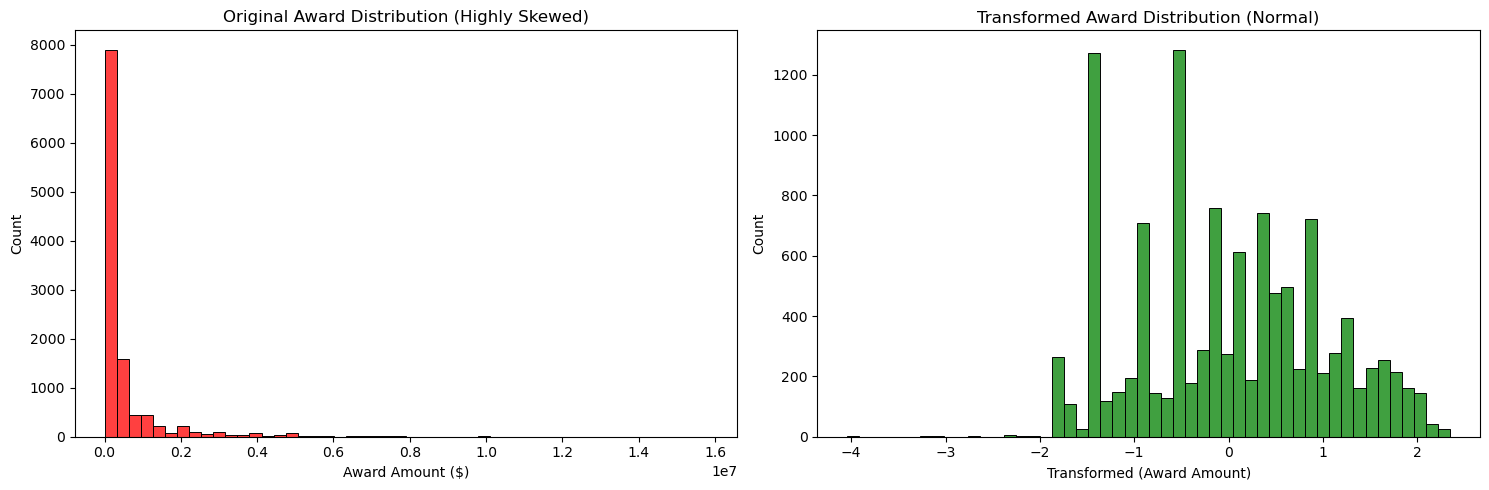

In [139]:
#plotting before vs after log transformation

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Original Skewed Data
sns.histplot(df['Award'], bins=50, ax=axes[0], color='red')
axes[0].set_title('Original Award Distribution (Highly Skewed)')
axes[0].set_xlabel('Award Amount ($)')

# Plot 2: Log-Transformed Data
sns.histplot(df['transformed_Awards'], bins=50, ax=axes[1], color='green')
axes[1].set_title('Transformed Award Distribution (Normal)')
axes[1].set_xlabel('Transformed (Award Amount)')

plt.tight_layout()
plt.show()

In [140]:
df['Fiscal_Year'].unique()

array([2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029],
      dtype=int64)

In [141]:
# Removing rows with years 2027 to 2029
df = df[~df['Fiscal_Year'].isin([2027, 2028, 2029])]

In [142]:
df['Fiscal_Year'].unique()

array([2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026], dtype=int64)

In [143]:
df.to_csv('engineered_yeojohnson.csv', index=False)

==========

Train Test Splitting - splitting the data into 5 features to be used for all models

==========

In [144]:
# 1. Splitting
X = df.drop(['Award', 'transformed_Awards'], axis=1)
y = df['transformed_Awards']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Target Encoding
# We use the raw Award from training to find the medians
train_temp = X_train.copy()
train_temp['Award'] = pt.inverse_transform(
    pd.DataFrame(y_train.values.reshape(-1, 1), columns=['Award'])
).ravel()

year_med = train_temp.groupby('Fiscal_Year')['Award'].median()
borough_med = train_temp.groupby('Borough')['Award'].median()
sector_med = train_temp.groupby('Sector')['Award'].median()
category_med = train_temp.groupby('Category')['Award'].median()

# Map and Fill
X_train['Year_Score'] = X_train['Fiscal_Year'].map(year_med).fillna(train_temp['Award'].median())
X_test['Year_Score'] = X_test['Fiscal_Year'].map(year_med).fillna(train_temp['Award'].median())

X_train['Borough_Score'] = X_train['Borough'].map(borough_med).fillna(train_temp['Award'].median())
X_test['Borough_Score'] = X_test['Borough'].map(borough_med).fillna(train_temp['Award'].median())

X_train['Sector_Score'] = X_train['Sector'].map(sector_med).fillna(train_temp['Award'].median())
X_test['Sector_Score'] = X_test['Sector'].map(sector_med).fillna(train_temp['Award'].median())

X_train['Category_Score'] = X_train['Category'].map(category_med).fillna(train_temp['Award'].median())
X_test['Category_Score'] = X_test['Category'].map(category_med).fillna(train_temp['Award'].median())


# Dropping unnecessary columns
to_drop = ['Borough', 'Council_District_num', 'Category', 'Sector']
X_train.drop(columns=to_drop, inplace=True)
X_test.drop(columns=to_drop, inplace=True)

# Ensure both have same columns (if a borough was missing in test)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)


In [145]:
#Scaling each column in X_train and X_test
# 1. Initialize the scaler and tell it to output Pandas DataFrames
scaler = StandardScaler().set_output(transform="pandas")
scaler_y = StandardScaler()

# 2. Fit and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# 3. Transform the test data
X_test_scaled = scaler.transform(X_test)

# 4. Reshaping log_awards to work with Scratch
X_train_scaled_reshaped = X_train_scaled.values.reshape(-1,1)
X_test_scaled_reshaped = X_test_scaled.values.reshape(-1,1)
y_train_reshaped = y_train.values.reshape(-1,1)
y_test_reshaped = y_test.values.reshape(-1,1)

y_train_scaled = scaler_y.fit_transform(y_train_reshaped)
y_test_scaled = scaler_y.transform(y_test_reshaped)

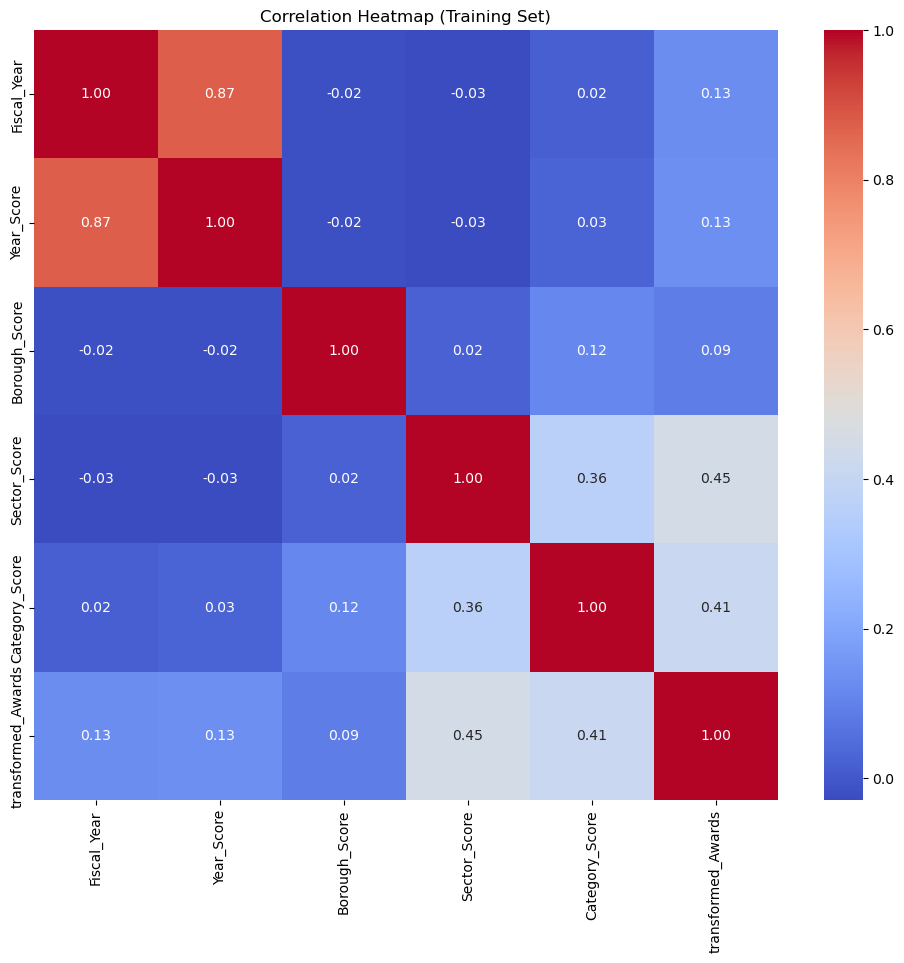

In [146]:
#correlation graph between X_train and y_train
# 1. Combine X_train and y_train into one DataFrame
# We do this to see the correlation between features AND the target
train_df = pd.concat([X_train, y_train], axis=1)

# 2. Calculate the correlation matrix
corr_matrix = train_df.corr()

# 3. Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Training Set)")
plt.show()

==========

Simple Linear Regression 

==========

In [147]:
class LinearRegressionScratch:

    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.coef_ = None
        self.intercept_ = None
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations

    def fit(self, X, y):
        m, n_features = X.shape
        
        # 1. Initialize weights to zeros
        self.coef_ = np.zeros((n_features, 1))
        self.intercept_ = 0.0

        for _ in range(self.n_iterations):
            # Calculate the predictions
            y_pred = self.predict(X)

            # 2. Compute the RESIDUALS (Derivative base)
            residuals = y_pred - y  

            # 3. Calculate the gradients correctly
            # Derivative of MSE with respect to intercept
            intercept_gradient = (2/m) * np.sum(residuals)
            
            # Derivative of MSE with respect to coefficients
            coef_gradient = (2/m) * np.dot(X.T, residuals)

            # 4. Update the parameters
            self.intercept_ -= self.learning_rate * intercept_gradient
            self.coef_ -= self.learning_rate * coef_gradient


    def predict(self, X):
        return np.dot(X, self.coef_) + self.intercept_
    
    def R_squared(self, y_true, y_pred):
        SSres = np.sum((y_true - y_pred)**2)
        SStot = np.sum((y_true - np.mean(y_true))**2)
        return 1 - (SSres/SStot)
    
    def MAE(self, y_true, y_pred):
        n = len(y_true)
        return (np.sum(np.abs(y_true - y_pred))) / n
    
    def MSE(self, y_true, y_pred):
        n = len(y_true)
        return (np.sum((y_true - y_pred)**2)) / n

In [148]:
# Assume learning rate and n_inter
lr = 0.01
n_iter = 1000

lin_reg_scratch = LinearRegressionScratch(learning_rate=lr, n_iterations=n_iter)

features_list = []
r2_list = []
r2_real_list = []
rmse_real_list = []
mae_real_list = []

#for loop to use all features for regression
for feature in X_train_scaled:

    lin_reg_scratch.fit(X_train_scaled[[feature]].values, y_train_reshaped)

    #Formatting
    print(f"Feature used = {feature}")
    print(f"Intercept : {lin_reg_scratch.intercept_}")
    print(f"Coef : {lin_reg_scratch.coef_[0][0]}")

    y_pred = lin_reg_scratch.predict(X_test_scaled[[feature]])


    # During evaluation
    y_test_real = pt.inverse_transform(
        pd.DataFrame(y_test.values.reshape(-1, 1), columns=['Award'])
    ).ravel()

    y_pred_real = pt.inverse_transform(
        pd.DataFrame(y_pred.reshape(-1, 1), columns=['Award'])
    ).ravel()
    

    #Evaluation MetricsS
    r2 = lin_reg_scratch.R_squared(y_test_reshaped, y_pred)
    r2_real = lin_reg_scratch.R_squared(y_test_real, y_pred_real)
    mse_real = lin_reg_scratch.MSE(y_test_real, y_pred_real)
    mae_real = lin_reg_scratch.MAE(y_test_real, y_pred_real)
    rmse_real = np.sqrt(mse_real)

    features_list.append(feature)
    r2_list.append(r2)
    r2_real_list.append(r2_real)
    rmse_real_list.append(rmse_real)
    mae_real_list.append(mae_real)

    print(f'R^2: {r2} | R^2 (real): {r2_real} | RMSE (real): ${rmse_real:,.2f} | MAE (real): ${mae_real:,.2f}\n')


Feature used = Fiscal_Year
Intercept : 0.00480922459335031
Coef : 0.12996663154837995
R^2: 0.021277557359867694 | R^2 (real): -0.09243023697196451 | RMSE (real): $1,200,651.14 | MAE (real): $445,259.48

Feature used = Year_Score
Intercept : 0.004809224593348343
Coef : 0.1343362388438187
R^2: 0.019331348974960805 | R^2 (real): -0.0921742583988856 | RMSE (real): $1,200,510.47 | MAE (real): $445,084.91

Feature used = Borough_Score
Intercept : 0.004809224593348426
Coef : 0.08851003323614355
R^2: 0.010664048494239742 | R^2 (real): -0.0927174792869403 | RMSE (real): $1,200,808.98 | MAE (real): $445,649.08

Feature used = Sector_Score
Intercept : 0.0048092245933484944
Coef : 0.44505113744642105
R^2: 0.17749626860050705 | R^2 (real): -0.017019445885730233 | RMSE (real): $1,158,469.52 | MAE (real): $424,953.23

Feature used = Category_Score
Intercept : 0.004809224593348422
Coef : 0.41081089657758074
R^2: 0.19119008884446875 | R^2 (real): -3892.757885316315 | RMSE (real): $71,681,065.76 | MAE (

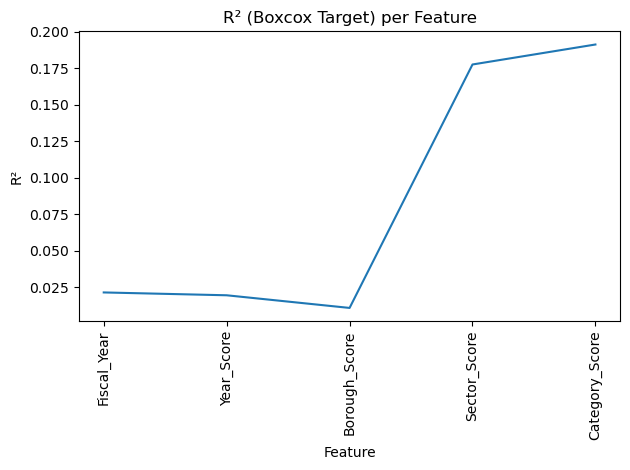

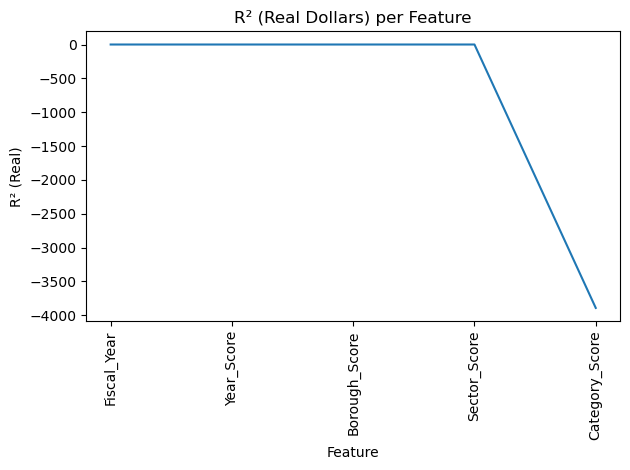

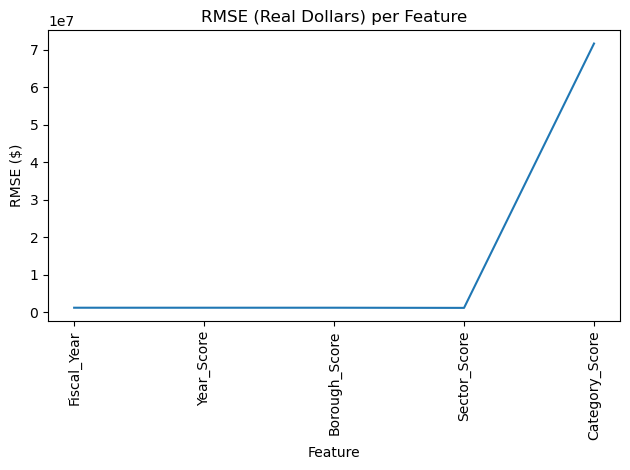

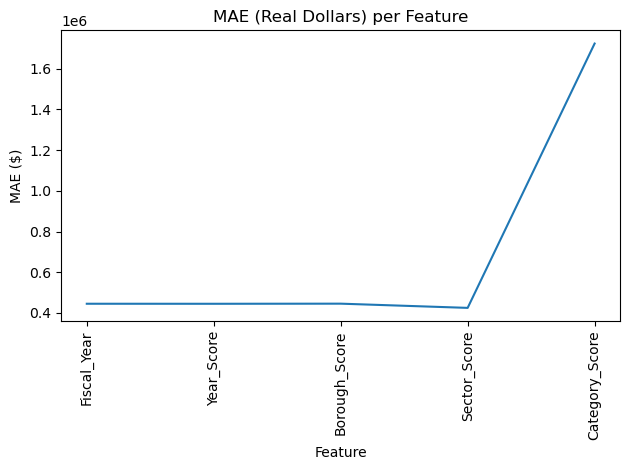

In [149]:
# R² (log target)
plt.figure()
plt.plot(features_list, r2_list)
plt.xticks(rotation=90)
plt.title("R² (Boxcox Target) per Feature")
plt.xlabel("Feature")
plt.ylabel("R²")
plt.tight_layout()
plt.show()

# R² (real dollars)
plt.figure()
plt.plot(features_list, r2_real_list)
plt.xticks(rotation=90)
plt.title("R² (Real Dollars) per Feature")
plt.xlabel("Feature")
plt.ylabel("R² (Real)")
plt.tight_layout()
plt.show()

# RMSE (real dollars)
plt.figure()
plt.plot(features_list, rmse_real_list)
plt.xticks(rotation=90)
plt.title("RMSE (Real Dollars) per Feature")
plt.xlabel("Feature")
plt.ylabel("RMSE ($)")
plt.tight_layout()
plt.show()

# MAE (real dollars)
plt.figure()
plt.plot(features_list, mae_real_list)
plt.xticks(rotation=90)
plt.title("MAE (Real Dollars) per Feature")
plt.xlabel("Feature")
plt.ylabel("MAE ($)")
plt.tight_layout()
plt.show()

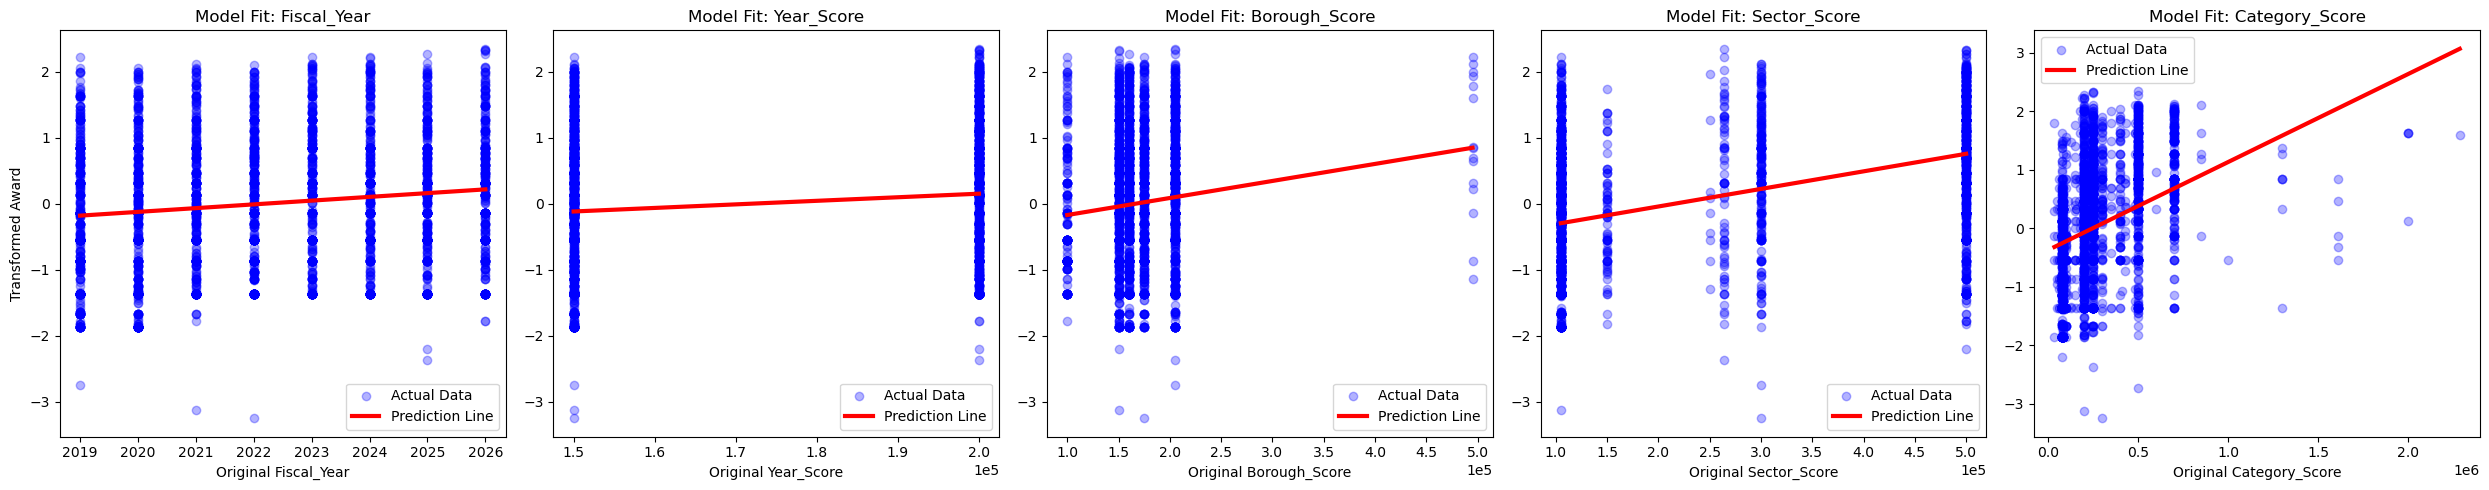

In [150]:
num_features = len(X_train_scaled.columns)
fig, axs = plt.subplots(nrows=1, ncols=num_features, figsize=(5 * num_features, 5))


# If you only have 1 feature, axs might not be an array. We handle that here:
if num_features == 1:
    axs = [axs]

for i, feature in enumerate(X_train_scaled.columns):
    
    # 1. Train and Predict using the SCALED data (The model needs this)
    lin_reg_scratch.fit(X_train_scaled[[feature]], y_train_reshaped)
    y_pred = lin_reg_scratch.predict(X_test_scaled[[feature]])
    
    # 2. Extract the ORIGINAL unscaled test data for the X-axis
    X_original = X_test[feature].values
    
    # 3. Sort the data! 
    # If we don't sort the original X values from smallest to largest, 
    # plt.plot will draw a chaotic zigzag connecting the random points.
    sorted_indices = np.argsort(X_original)
    X_original_sorted = X_original[sorted_indices]
    y_pred_sorted = y_pred[sorted_indices]
    
    # 4. Plot using the ORIGINAL X values, but the PREDICTED Y values
    axs[i].scatter(X_original, y_test_reshaped, color='blue', alpha=0.3, label='Actual Data')
    axs[i].plot(X_original_sorted, y_pred_sorted, color='red', linewidth=3, label='Prediction Line')
    
    # 5. Formatting
    axs[i].set_title(f"Model Fit: {feature}")
    axs[i].set_xlabel(f"Original {feature}") # Now this labels it as original!
    axs[i].ticklabel_format(style='sci', axis='x', scilimits=(0, 5))
    
    if i == 0:
        axs[i].set_ylabel("Transformed Award")
        
    axs[i].legend()

plt.tight_layout()
plt.show()

In [151]:
# Using sklearn lib
lin_reg = LinearRegression()

features_list = []
r2_list = []
r2_real_list = []
rmse_real_list = []
mae_real_list = []

#for loop to use all features for regression
for feature in X_train_scaled:

    lin_reg.fit(X_train_scaled[[feature]], y_train_reshaped)

    intercept_lib = lin_reg.intercept_
    coefficient_lib = lin_reg.coef_

    #Formatting
    print(f"Feature used = {feature}")
    print(f"Intercept : {intercept_lib.ravel()[0]}")
    print(f"Coef : {coefficient_lib.ravel()[0]}")

    # y_pred_lib = lin_reg.predict(X_test_scaled[[feature]])

    # #Evaluation Metrics
    # mse_lib = mean_squared_error(y_test_reshaped, y_pred_lib)
    # mae_lib = mean_absolute_error(y_test_reshaped, y_pred_lib)
    # r2_lib = r2_score(y_test_reshaped, y_pred_lib)

    y_pred = lin_reg.predict(X_test_scaled[[feature]])
    
    # During evaluation
    y_test_real = pt.inverse_transform(
        pd.DataFrame(y_test.values.reshape(-1, 1), columns=['Award'])
    ).ravel()

    y_pred_real = pt.inverse_transform(
        pd.DataFrame(y_pred.reshape(-1, 1), columns=['Award'])
    ).ravel()

    #Evaluation Metrics
    r2 = r2_score(y_test_reshaped, y_pred)
    r2_real = r2_score(y_test_real, y_pred_real)
    mse_real = mean_squared_error(y_test_real, y_pred_real)
    mae_real = mean_absolute_error(y_test_real, y_pred_real)
    rmse_real = np.sqrt(mse_real)

    features_list.append(feature)
    r2_list.append(r2)
    r2_real_list.append(r2_real)
    rmse_real_list.append(rmse_real)
    mae_real_list.append(mae_real)


    print(f'R^2: {r2} | R^2 (real): {r2_real} | RMSE (real): ${rmse_real:,.2f} | MAE (real): ${mae_real:,.2f}\n')

Feature used = Fiscal_Year
Intercept : 0.004809224601444088
Coef : 0.12996663176710946
R^2: 0.021277557367240796 | R^2 (real): -0.09243023696134811 | RMSE (real): $1,200,651.14 | MAE (real): $445,259.48

Feature used = Year_Score
Intercept : 0.004809224601442125
Coef : 0.13433623906990264
R^2: 0.019331348977489338 | R^2 (real): -0.09217425838767257 | RMSE (real): $1,200,510.47 | MAE (real): $445,084.91

Feature used = Borough_Score
Intercept : 0.004809224601442203
Coef : 0.0885100333851029
R^2: 0.010664048498868817 | R^2 (real): -0.09271747927276164 | RMSE (real): $1,200,808.98 | MAE (real): $445,649.08

Feature used = Sector_Score
Intercept : 0.004809224601442275
Coef : 0.4450511381954234
R^2: 0.1774962685621423 | R^2 (real): -0.01701944568248015 | RMSE (real): $1,158,469.52 | MAE (real): $424,953.23

Feature used = Category_Score
Intercept : 0.0048092246014422085
Coef : 0.41081089726896197
R^2: 0.19119008901100132 | R^2 (real): -3892.758644935428 | RMSE (real): $71,681,072.75 | MAE (

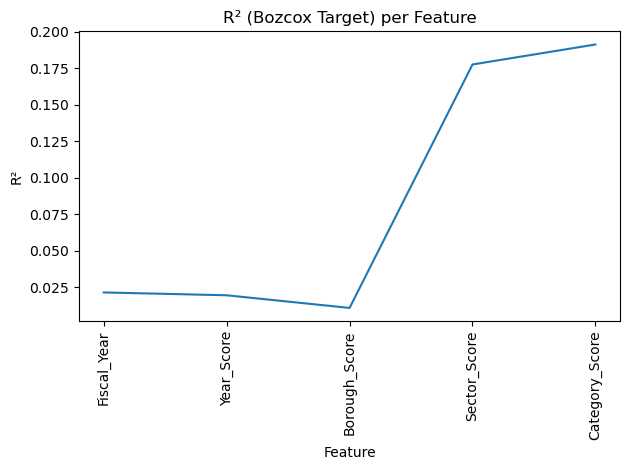

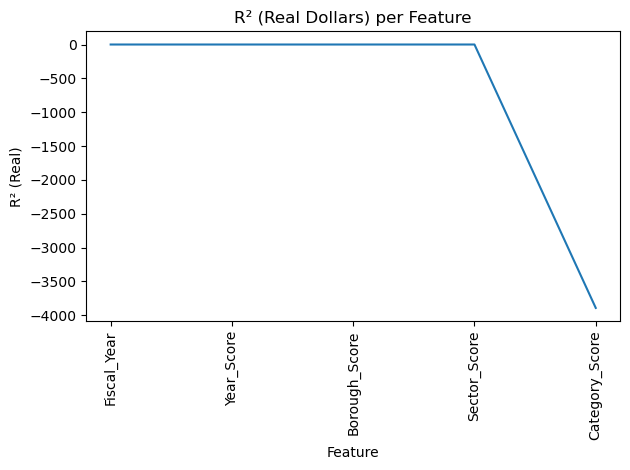

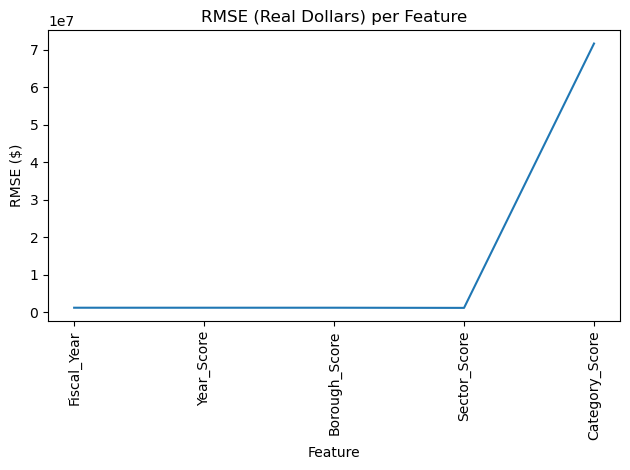

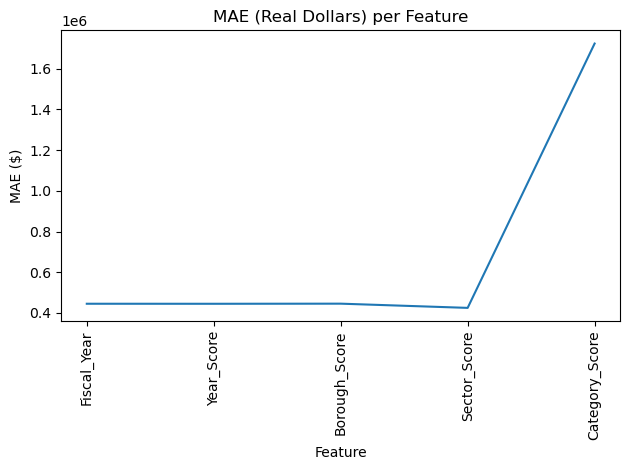

In [152]:
# R² (log target)
plt.figure()
plt.plot(features_list, r2_list)
plt.xticks(rotation=90)
plt.title("R² (Bozcox Target) per Feature")
plt.xlabel("Feature")
plt.ylabel("R²")
plt.tight_layout()
plt.show()

# R² (real dollars)
plt.figure()
plt.plot(features_list, r2_real_list)
plt.xticks(rotation=90)
plt.title("R² (Real Dollars) per Feature")
plt.xlabel("Feature")
plt.ylabel("R² (Real)")
plt.tight_layout()
plt.show()

# RMSE (real dollars)
plt.figure()
plt.plot(features_list, rmse_real_list)
plt.xticks(rotation=90)
plt.title("RMSE (Real Dollars) per Feature")
plt.xlabel("Feature")
plt.ylabel("RMSE ($)")
plt.tight_layout()
plt.show()

# MAE (real dollars)
plt.figure()
plt.plot(features_list, mae_real_list)
plt.xticks(rotation=90)
plt.title("MAE (Real Dollars) per Feature")
plt.xlabel("Feature")
plt.ylabel("MAE ($)")
plt.tight_layout()
plt.show()

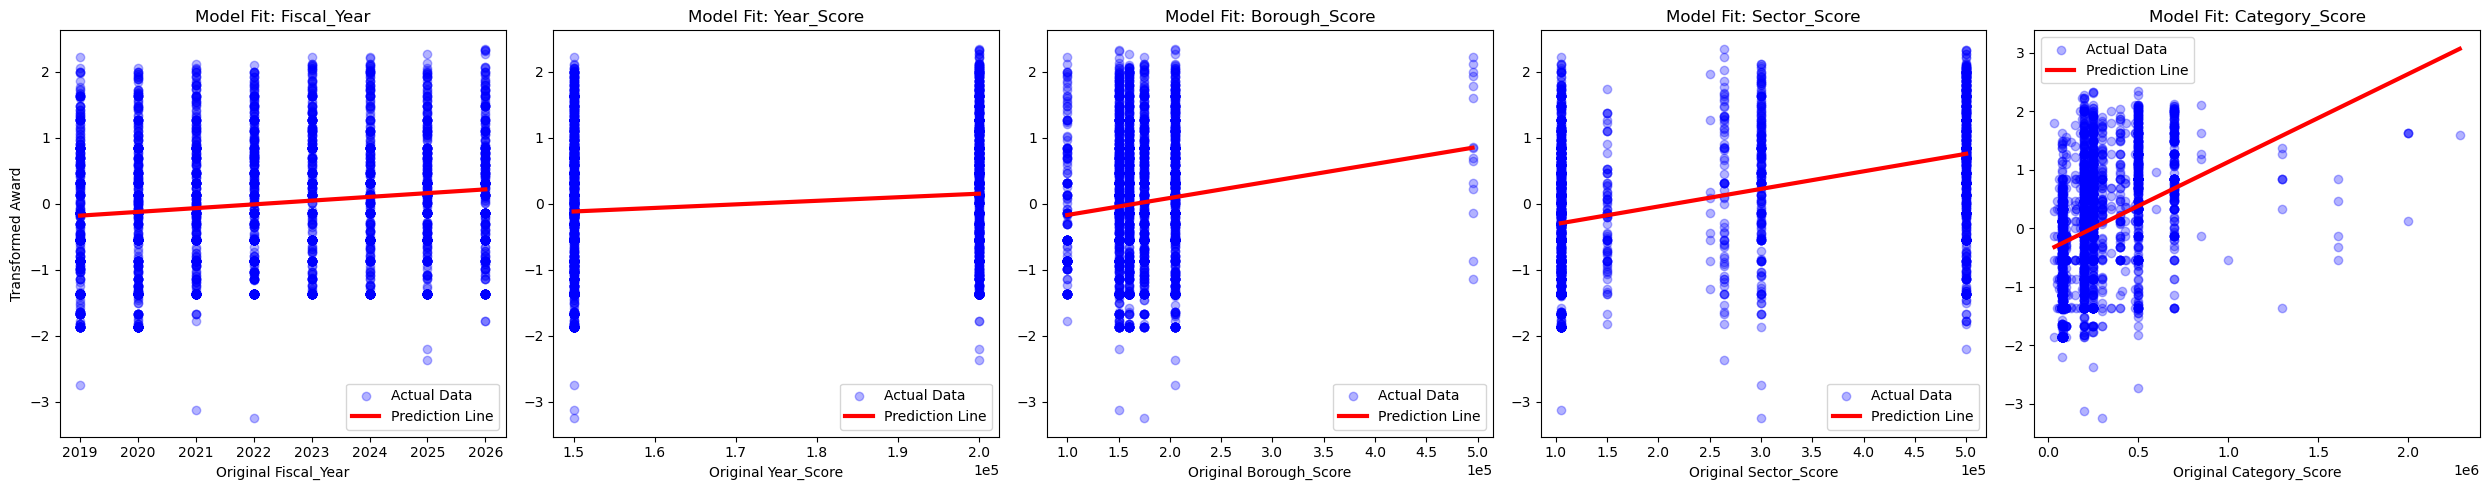

In [153]:
num_features = len(X_train_scaled.columns)
fig, axs = plt.subplots(nrows=1, ncols=num_features, figsize=(5 * num_features, 5))

# If you only have 1 feature, axs might not be an array. We handle that here:
if num_features == 1:
    axs = [axs]

for i, feature in enumerate(X_train_scaled.columns):
    
    # 1. Train and Predict using the SCALED data (The model needs this)
    lin_reg.fit(X_train_scaled[[feature]], y_train_reshaped)
    y_pred = lin_reg.predict(X_test_scaled[[feature]])
    
    # 2. Extract the ORIGINAL unscaled test data for the X-axis
    X_original = X_test[feature].values
    
    # 3. Sort the data! 
    # If we don't sort the original X values from smallest to largest, 
    # plt.plot will draw a chaotic zigzag connecting the random points.
    sorted_indices = np.argsort(X_original)
    X_original_sorted = X_original[sorted_indices]
    y_pred_sorted = y_pred[sorted_indices]
    
    # 4. Plot using the ORIGINAL X values, but the PREDICTED Y values
    axs[i].scatter(X_original, y_test_reshaped, color='blue', alpha=0.3, label='Actual Data')
    axs[i].plot(X_original_sorted, y_pred_sorted, color='red', linewidth=3, label='Prediction Line')
    
    # 5. Formatting
    axs[i].set_title(f"Model Fit: {feature}")
    axs[i].set_xlabel(f"Original {feature}") # Now this labels it as original!
    axs[i].ticklabel_format(style='sci', axis='x', scilimits=(0, 5))
    
    if i == 0:
        axs[i].set_ylabel("Transformed Award")
        
    axs[i].legend()

plt.tight_layout()
plt.show()

Both result in not-so-ideal R2, MSE and MAE scores which is to be expected.

==========

Multiple Linear Regression:

==========

- Multiple Regression using GLOBAL MEDIANS

In [154]:
model_multi_scratch = LinearRegressionScratch()
model_multi_scratch.fit(X_train_scaled, y_train_reshaped)

y_pred = model_multi_scratch.predict(X_test_scaled)

# During evaluation
y_test_real = pt.inverse_transform(
    pd.DataFrame(y_test.values.reshape(-1, 1), columns=['Award'])
).ravel()

y_pred_real = pt.inverse_transform(
    pd.DataFrame(y_pred.reshape(-1, 1), columns=['Award'])
).ravel()

#Evaluation Metrics
r2 = model_multi_scratch.R_squared(y_test_reshaped, y_pred)
r2_real = model_multi_scratch.R_squared(y_test_real, y_pred_real)
mse_real = model_multi_scratch.MSE(y_test_real, y_pred_real)
mae_real = model_multi_scratch.MAE(y_test_real, y_pred_real)
rmse_real = np.sqrt(mse_real)

print(f'R^2: {r2} | R^2 (real): {r2_real} | RMSE (real): ${rmse_real:,.2f} | MAE (real): ${mae_real:,.2f}\n')




R^2: 0.27666706832391885 | R^2 (real): -0.7847778571537432 | RMSE (real): $1,534,659.62 | MAE (real): $446,728.16



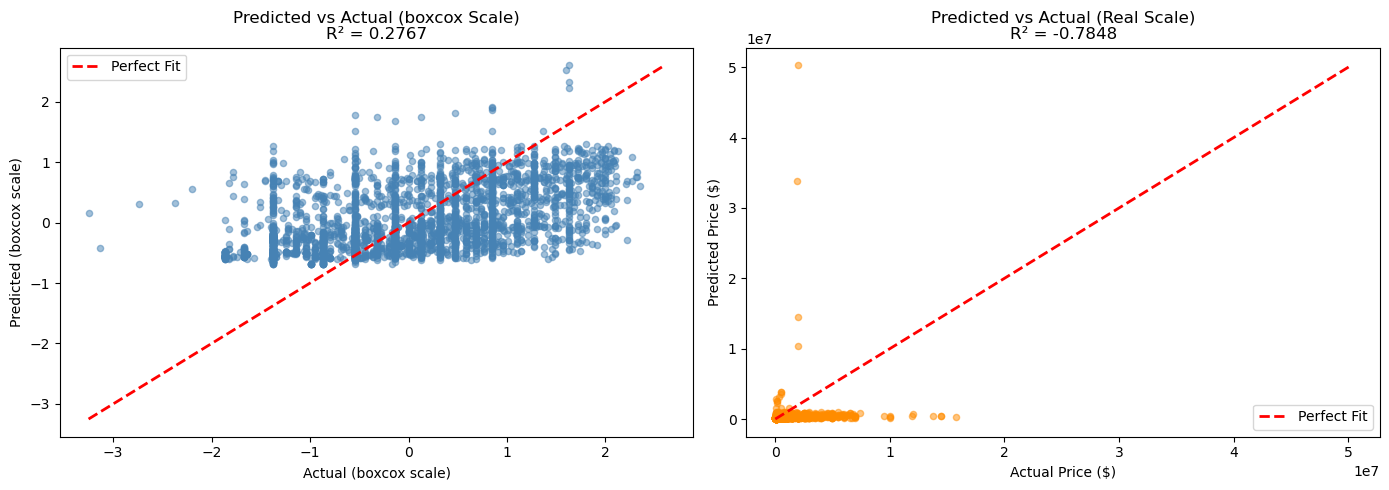

In [155]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log-scale space
axes[0].scatter(y_test_reshaped, y_pred, alpha=0.5, color='steelblue', s=20)
min_val, max_val = min(y_test_reshaped.min(), y_pred.min()), max(y_test_reshaped.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit')
axes[0].set_xlabel('Actual (boxcox scale)')
axes[0].set_ylabel('Predicted (boxcox scale)')
axes[0].set_title(f'Predicted vs Actual (boxcox Scale)\nR² = {r2:.4f}')
axes[0].legend()

# Real-scale space
axes[1].scatter(y_test_real, y_pred_real, alpha=0.5, color='darkorange', s=20)
min_val, max_val = min(y_test_real.min(), y_pred_real.min()), max(y_test_real.max(), y_pred_real.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit')
axes[1].set_xlabel('Actual Price ($)')
axes[1].set_ylabel('Predicted Price ($)')
axes[1].set_title(f'Predicted vs Actual (Real Scale)\nR² = {r2_real:.4f}')
axes[1].legend()

plt.tight_layout()
plt.show()

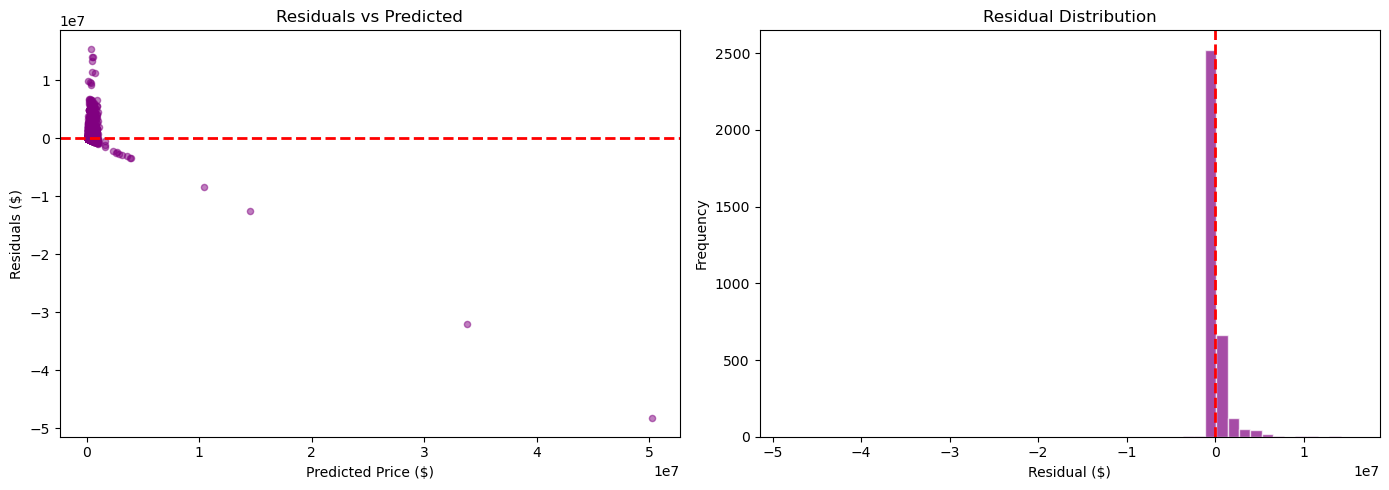

In [156]:
residuals = y_test_real - y_pred_real

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred_real, residuals, alpha=0.5, color='purple', s=20)
axes[0].axhline(0, color='red', linestyle='--', lw=2)
axes[0].set_xlabel('Predicted Price ($)')
axes[0].set_ylabel('Residuals ($)')
axes[0].set_title('Residuals vs Predicted')

# Residual Distribution
axes[1].hist(residuals, bins=50, color='purple', edgecolor='white', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Residual ($)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

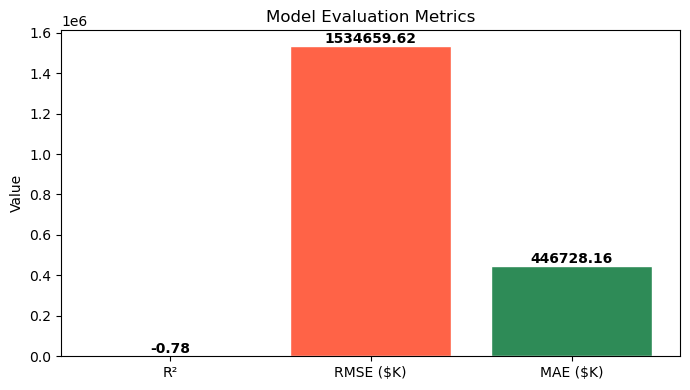

In [157]:
metrics = {'R²': r2_real, 'RMSE ($K)': rmse_real, 'MAE ($K)': mae_real}

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(metrics.keys(), metrics.values(), color=['steelblue', 'tomato', 'seagreen'], edgecolor='white')

for bar, val in zip(bars, metrics.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', va='bottom', fontweight='bold')

ax.set_title('Model Evaluation Metrics')
ax.set_ylabel('Value')
plt.tight_layout()
plt.show()

In [158]:
# using sklearn lib
model_multi = LinearRegression()
model_multi.fit(X_train_scaled,y_train_reshaped)

y_pred = model_multi.predict(X_test_scaled)

# During evaluation
y_test_real = pt.inverse_transform(
    pd.DataFrame(y_test.values.reshape(-1, 1), columns=['Award'])
).ravel()

y_pred_real = pt.inverse_transform(
    pd.DataFrame(y_pred.reshape(-1, 1), columns=['Award'])
).ravel()

#Evaluation Metrics
r2 = r2_score(y_test_reshaped, y_pred)
r2_real = r2_score(y_test_real, y_pred_real)
mse_real = mean_squared_error(y_test_real, y_pred_real)
mae_real = mean_absolute_error(y_test_real, y_pred_real)
rmse_real = np.sqrt(mse_real)

print(f'R^2: {r2} | R^2 (real): {r2_real} | RMSE (real): ${rmse_real:,.2f} | MAE (real): ${mae_real:,.2f}\n')


R^2: 0.276664169698157 | R^2 (real): -0.7841699371583963 | RMSE (real): $1,534,398.24 | MAE (real): $446,718.59



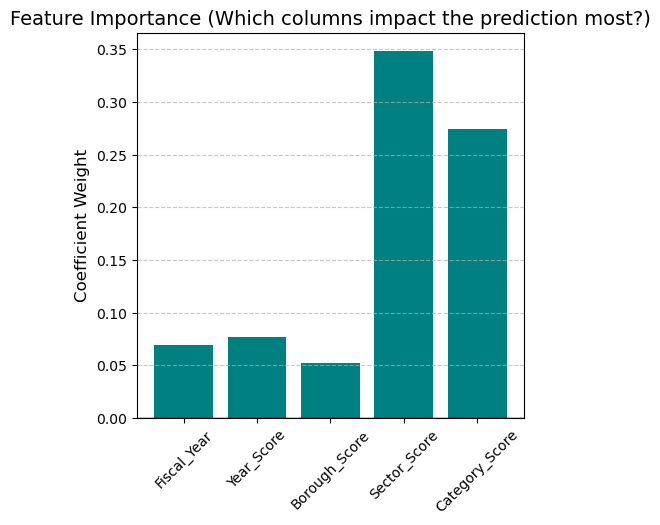

In [159]:
# Plotting Feature Importance (Coefficients)
plt.figure(figsize=(5, 5))

# Get feature names from the Pandas dataframe and flatten the coefficients array
feature_names = X_train_scaled.columns
coefficients = model_multi_scratch.coef_.flatten()

# Create a bar chart
plt.bar(feature_names, coefficients, color='teal')
plt.title('Feature Importance (Which columns impact the prediction most?)', fontsize=14)
plt.ylabel('Coefficient Weight', fontsize=12)
plt.axhline(y=0, color='black', linewidth=1)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

- The Feature-Based Median section results in worse overall evaluation scores, so we'll stick with the GLOBAL MEDIAN method.
- Council_District is no longer considered due to its extremely varied data entries.

Using sklearn lib:


==========

Polynomial Regression:

==========

In [160]:
# Assume learning rate and n_inter
lr = 0.001
n_iter = 10000

- Polynomial Regression with all Feature Combinations (independent variables and mulitple independent variables)
- Using same data split as multiple linear regression (global medians included)

In [161]:
for d in range(1, 6):
    model_poly = Pipeline([
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        ("scaler", StandardScaler()),
        ("reg", LinearRegression())
    ])
    
    model_poly.fit(X_train, y_train_reshaped)
    print(f"Degree {d}")

    y_pred = model_poly.predict(X_test)

    # During evaluation
    y_test_real = pt.inverse_transform(
        pd.DataFrame(y_test.values.reshape(-1, 1), columns=['Award'])
    ).ravel()

    y_pred_real = pt.inverse_transform(
        pd.DataFrame(y_pred.reshape(-1, 1), columns=['Award'])
    ).ravel()

    # Safety measures - replace NaN/inf with median fallback
    test_median = np.nanmedian(y_test_real)
    pred_median = np.nanmedian(y_pred_real)
    
    y_test_real = np.where(np.isfinite(y_test_real), y_test_real, test_median)
    y_pred_real = np.where(np.isfinite(y_pred_real), y_pred_real, pred_median)

    # # Report how many were replaced
    # test_nans = np.isnan(y_test_real).sum()
    # pred_nans = np.isnan(y_pred_real).sum()
    # if test_nans > 0 or pred_nans > 0:
    #     print(f"  ⚠️ Replaced {test_nans} NaNs in y_test_real, {pred_nans} NaNs in y_pred_real")

    # Evaluation Metrics
    r2 = r2_score(y_test, y_pred)
    r2_real = r2_score(y_test_real, y_pred_real)
    mse_real = mean_squared_error(y_test_real, y_pred_real)
    mae_real = mean_absolute_error(y_test_real, y_pred_real)
    rmse_real = np.sqrt(mse_real)

    print(f'R^2: {r2} | R^2 (real): {r2_real} | RMSE (real): ${rmse_real:,.2f} | MAE (real): ${mae_real:,.2f}\n')

Degree 1
R^2: 0.2766641696981569 | R^2 (real): -0.7841699371583677 | RMSE (real): $1,534,398.24 | MAE (real): $446,718.59

Degree 2
R^2: 0.3206895317216011 | R^2 (real): -0.24969319304123294 | RMSE (real): $1,284,167.53 | MAE (real): $426,205.43

Degree 3
R^2: 0.34660494784837736 | R^2 (real): 0.031640420850869044 | RMSE (real): $1,130,416.03 | MAE (real): $405,202.53

Degree 4
R^2: 0.34897037315282997 | R^2 (real): -0.05841228561387912 | RMSE (real): $1,181,809.34 | MAE (real): $410,691.83

Degree 5
R^2: 0.2899456023940994 | R^2 (real): -154.78529637733143 | RMSE (real): $14,337,822.99 | MAE (real): $689,448.67



- Individual Polynomial Regression (From Scratch)

In [162]:
class PolyRegressionScratch:

    def __init__(self, degree=2, learning_rate=0.01, n_iterations=1000):
        self.degree = degree
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        
        self.coef_ = None
        self.intercept_ = None
        
        # New attributes to store scaling parameters
        self.feature_means_ = None
        self.feature_stds_ = None

    def _polynomial_features(self, X):
        X_poly = X.copy()

        # Add higher degree terms
        for d in range(2, self.degree + 1):
            X_poly = np.concatenate((X_poly, X ** d), axis=1)
        
        return X_poly

    def _scale_features(self, X_poly, is_training=False):
        if is_training:
            self.feature_means_ = np.mean(X_poly, axis=0)
            # Add 1e-8 to prevent division by zero in case of constant features
            self.feature_stds_ = np.std(X_poly, axis=0) + 1e-8
            
        return (X_poly - self.feature_means_) / self.feature_stds_
    
    def fit(self, X, y):
        X = np.array(X)  # handle DataFrames
        y = np.array(y)

        if len(y.shape) == 1:
            y = y.reshape(-1, 1)

        X_poly = self._polynomial_features(X)
        X_poly_scaled = self._scale_features(X_poly, is_training=True)
        
        m, n_features = X_poly_scaled.shape
        
        self.coef_ = np.zeros((n_features, 1))
        self.intercept_ = 0.0

        for _ in range(self.n_iterations):
            y_pred = np.dot(X_poly_scaled, self.coef_) + self.intercept_
            residuals = y_pred - y

            intercept_gradient = (2/m) * np.sum(residuals)
            coef_gradient = (2/m) * np.dot(X_poly_scaled.T, residuals)

            self.intercept_ -= self.learning_rate * intercept_gradient
            self.coef_ -= self.learning_rate * coef_gradient

            # Early stop if gradients explode
            if np.any(np.isnan(self.coef_)) or np.any(np.isinf(self.coef_)):
                print(f"Warning: Divergence detected, stopping early at iteration {_}")
                break

    def predict(self, X):
        X = np.array(X)  # handle DataFrames
        X_poly = self._polynomial_features(X)
        X_poly_scaled = self._scale_features(X_poly, is_training=False)
        return np.dot(X_poly_scaled, self.coef_) + self.intercept_

    def R_squared(self, y_true, y_pred):
        SSres = np.sum((y_true - y_pred)**2)
        SStot = np.sum((y_true - np.mean(y_true))**2)
        return 1 - (SSres/SStot)

    def MAE(self, y_true, y_pred):
        n = len(y_true)
        return np.sum(np.abs(y_true - y_pred)) / n

    def MSE(self, y_true, y_pred):
        n = len(y_true)
        return np.sum((y_true - y_pred)**2) / n

- X_test and X_train = a dataframe containing Fiscal_Year, Year_Score, Borough_Score, Sector_Score, Category_Score

In [163]:
for degree in range(2, 6):
    for feature in X_train:
        poly_reg_scratch = PolyRegressionScratch(degree=degree, learning_rate=lr, n_iterations=n_iter)
        poly_reg_scratch.fit(X_train[[feature]], y_train_reshaped)

        print(f"Degree {degree} | Feature: {feature}")

        y_pred = poly_reg_scratch.predict(X_test[[feature]]).reshape(-1, 1)  # ← fixed

        y_test_real = pt.inverse_transform(
            pd.DataFrame(y_test.values.reshape(-1, 1), columns=['Award'])
        ).ravel()

        y_pred_real = pt.inverse_transform(
            pd.DataFrame(y_pred.reshape(-1, 1), columns=['Award'])
        ).ravel()

        test_median = np.nanmedian(y_test_real)
        pred_median = np.nanmedian(y_pred_real)
        
        y_test_real = np.where(np.isfinite(y_test_real), y_test_real, test_median)
        y_pred_real = np.where(np.isfinite(y_pred_real), y_pred_real, pred_median)

        r2 = poly_reg_scratch.R_squared(y_test_reshaped, y_pred)
        r2_real = poly_reg_scratch.R_squared(y_test_real, y_pred_real)
        mse_real = poly_reg_scratch.MSE(y_test_real, y_pred_real)
        mae_real = poly_reg_scratch.MAE(y_test_real, y_pred_real)
        rmse_real = np.sqrt(mse_real)

        print(f'R^2: {r2} | R^2 (real): {r2_real} | RMSE (real): ${rmse_real:,.2f} | MAE (real): ${mae_real:,.2f}\n')

Degree 2 | Feature: Fiscal_Year
R^2: 0.021274352149584064 | R^2 (real): -0.0924304207062221 | RMSE (real): $1,200,651.24 | MAE (real): $445,259.66

Degree 2 | Feature: Year_Score
R^2: 0.019331348977842278 | R^2 (real): -0.09217425838873572 | RMSE (real): $1,200,510.47 | MAE (real): $445,084.91

Degree 2 | Feature: Borough_Score
R^2: 0.010616565530374045 | R^2 (real): -0.09272309616210173 | RMSE (real): $1,200,812.07 | MAE (real): $445,666.59

Degree 2 | Feature: Sector_Score
R^2: 0.1755264316527929 | R^2 (real): -0.017714860845757352 | RMSE (real): $1,158,865.52 | MAE (real): $425,261.06

Degree 2 | Feature: Category_Score
R^2: 0.2299769848653872 | R^2 (real): -13478.284230825184 | RMSE (real): $133,368,540.22 | MAE (real): $5,542,202.12

Degree 3 | Feature: Fiscal_Year
R^2: 0.021271152925994463 | R^2 (real): -0.09243060527031766 | RMSE (real): $1,200,651.34 | MAE (real): $445,259.84

Degree 3 | Feature: Year_Score
R^2: 0.019331348977842167 | R^2 (real): -0.09217425838873572 | RMSE (re

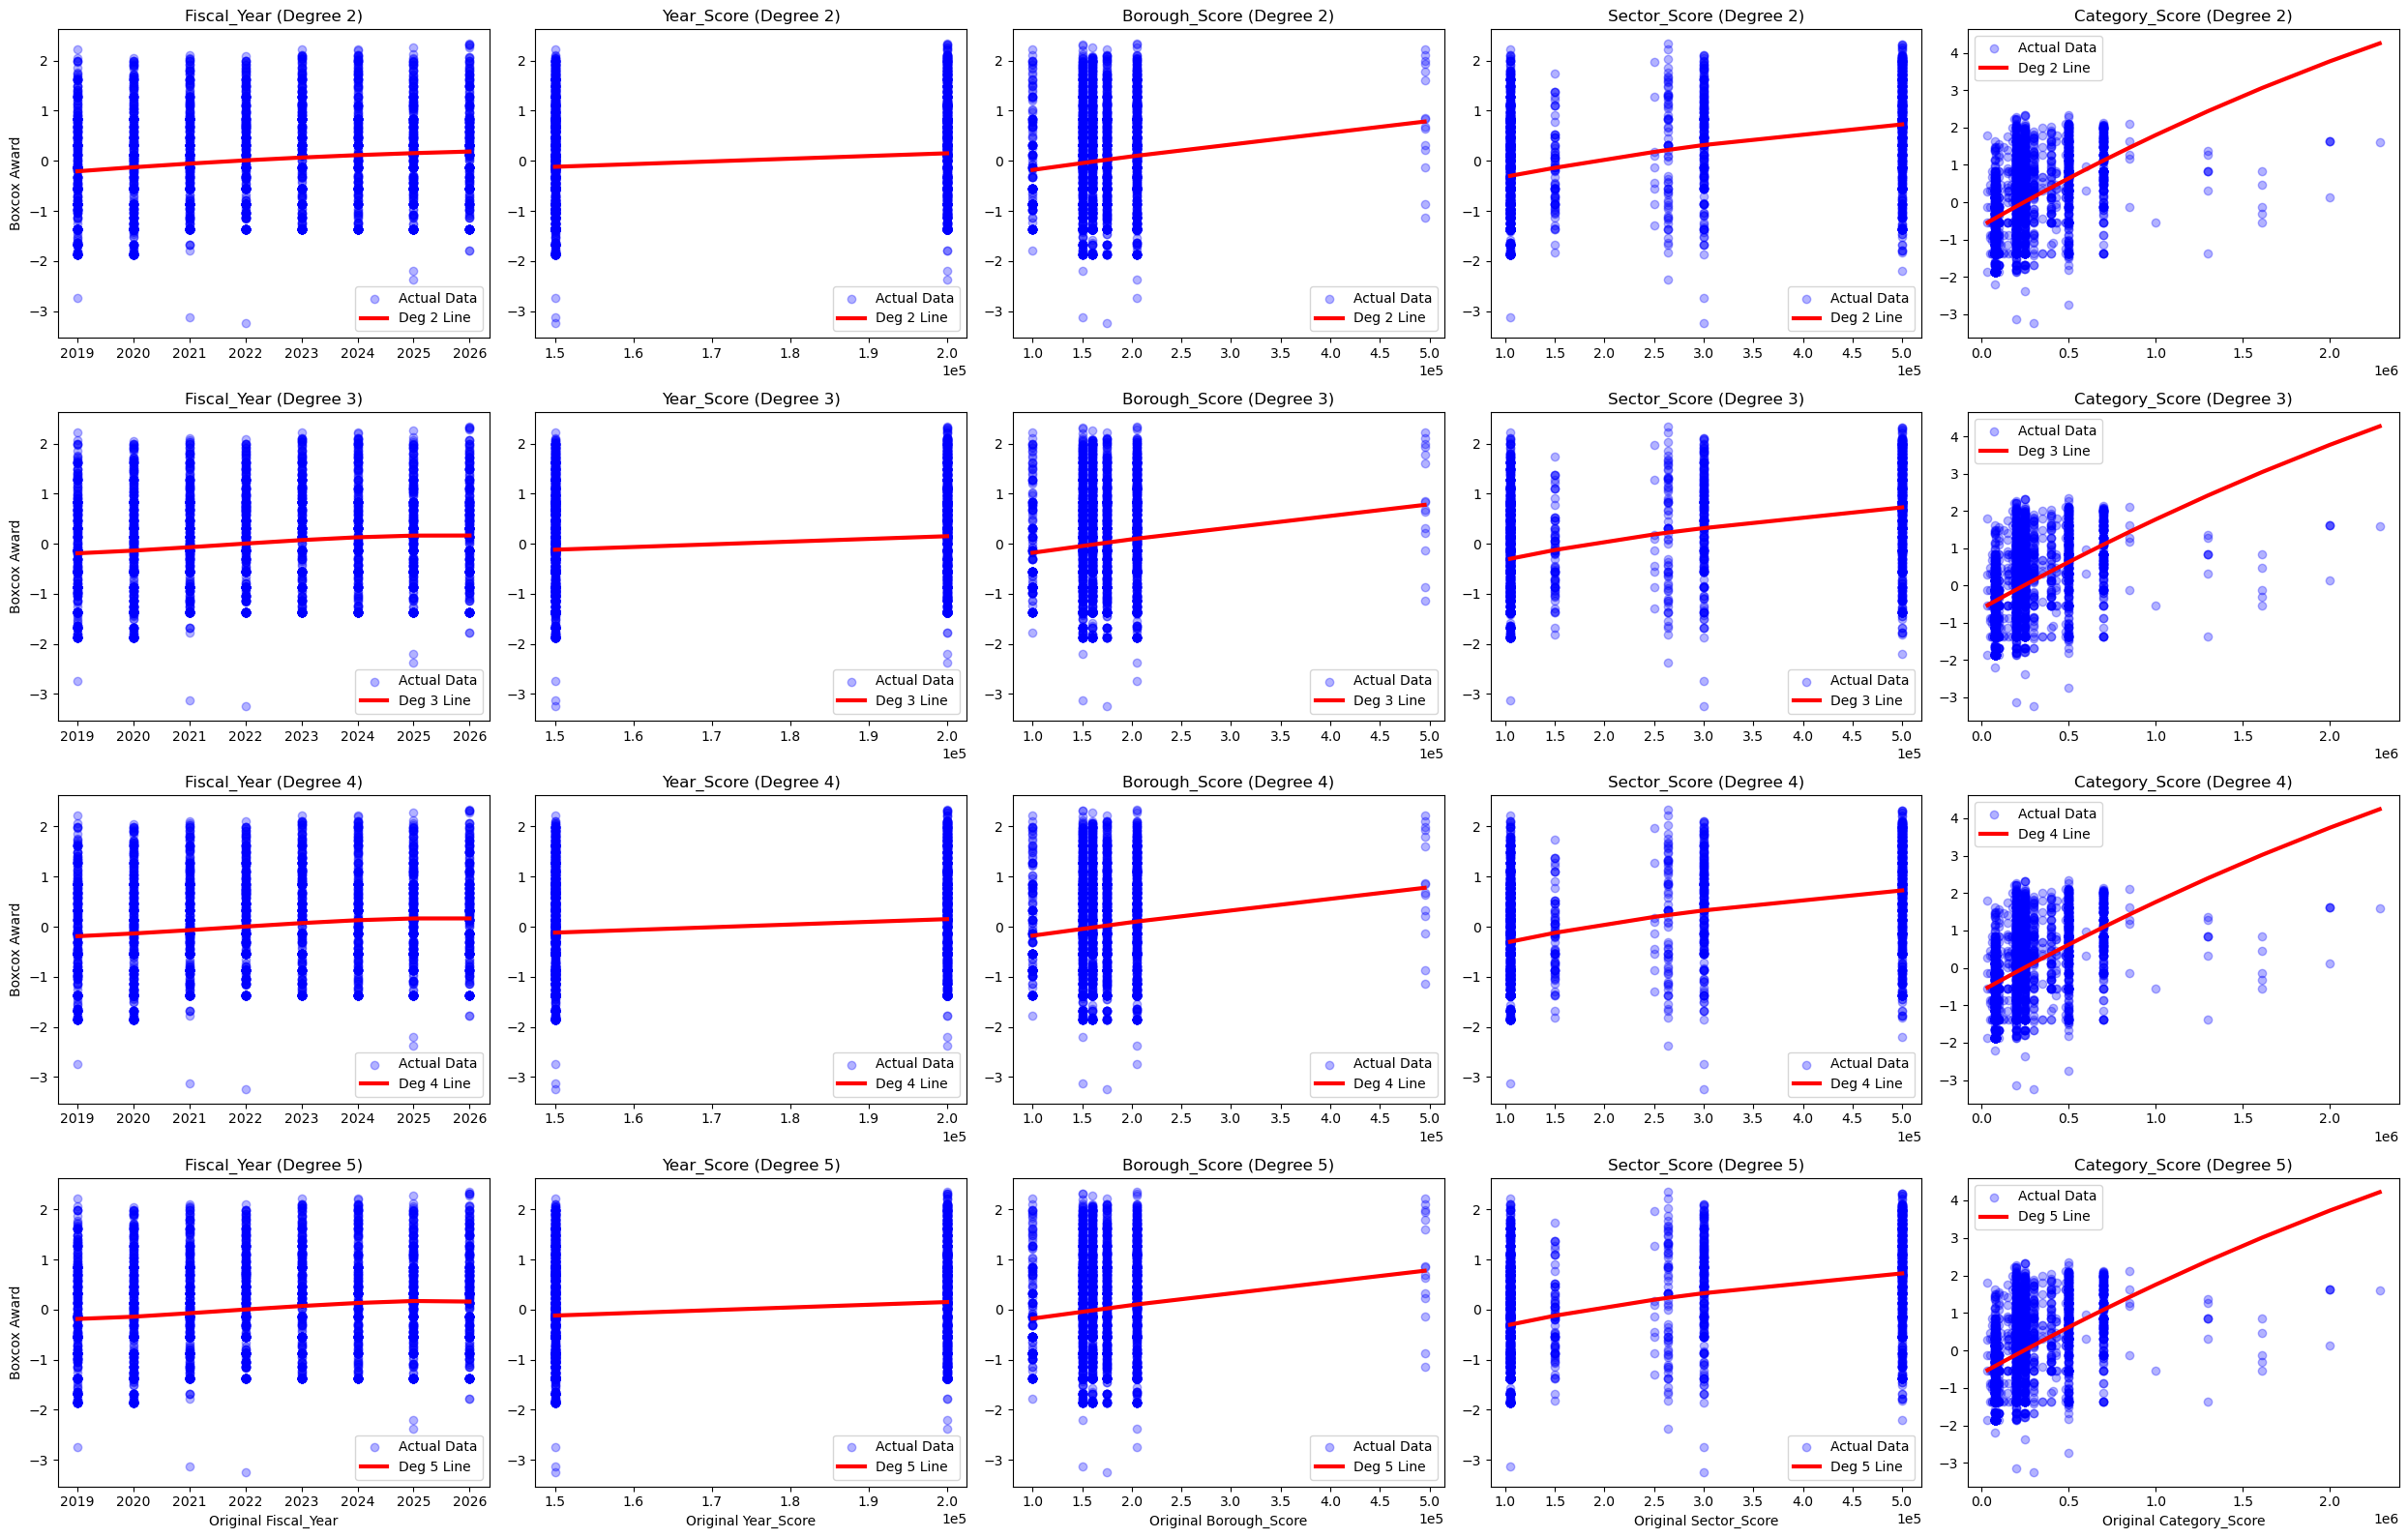

In [164]:
degrees = [2, 3, 4, 5] # The rows

num_degrees = len(degrees)
num_features = len(X_train_scaled.columns)

# Create the 2D grid of subplots (squeeze=False guarantees it stays a 2D array)
fig, axs = plt.subplots(nrows=num_degrees, ncols=num_features, 
                        figsize=(5 * num_features, 4 * num_degrees), 
                        squeeze=False)

for row_idx, degree in enumerate(degrees):
    for col_idx, feature in enumerate(X_train_scaled.columns):
        
        # Select the specific subplot for this Degree + Feature combo
        ax = axs[row_idx, col_idx]
        
        # 1. Initialize and Train the Polynomial Model
        poly_reg = PolyRegressionScratch(degree=degree, learning_rate=lr, n_iterations=n_iter)
        poly_reg.fit(X_train_scaled[[feature]], y_train_reshaped)
        
        # Predict on the scaled test data
        y_pred = poly_reg.predict(X_test_scaled[[feature]])
        
        # 2. Extract the ORIGINAL unscaled test data for the X-axis
        X_original = X_test[feature].values
        
        # 3. Sort the data! (CRITICAL FOR POLYNOMIALS)
        # If you don't sort a curve, Matplotlib will draw a massive scribble connecting the dots
        sorted_indices = np.argsort(X_original)
        X_original_sorted = X_original[sorted_indices]
        y_pred_sorted = y_pred[sorted_indices]
        
        # 4. Plot using the ORIGINAL X values, but the PREDICTED Y values
        ax.scatter(X_original, y_test_reshaped, color='blue', alpha=0.3, label='Actual Data')
        ax.plot(X_original_sorted, y_pred_sorted, color='red', linewidth=3, label=f'Deg {degree} Line')
        
        # 5. Formatting
        ax.set_title(f"{feature} (Degree {degree})")
        
        # Only put X labels on the very bottom row to keep it clean
        if row_idx == num_degrees - 1:
            ax.set_xlabel(f"Original {feature}")
        ax.ticklabel_format(style='sci', axis='x', scilimits=(0, 5))
            
        # Only put Y labels on the far left column
        if col_idx == 0:
            ax.set_ylabel("Boxcox Award")
            
        ax.legend()

plt.tight_layout()
plt.show()

In [165]:
# multiple polynomial regression

for d in range(2, 6):
    multi_model_poly = PolyRegressionScratch(degree=d, learning_rate=lr, n_iterations=n_iter)
    multi_model_poly.fit(X_train, y_train_reshaped)
    
    print(f"Degree {d}")

    y_pred = multi_model_poly.predict(X_test).reshape(-1, 1)  # ← fixed
    
    y_test_real = pt.inverse_transform(
        pd.DataFrame(y_test.values.reshape(-1, 1), columns=['Award'])
    ).ravel()

    y_pred_real = pt.inverse_transform(
        pd.DataFrame(y_pred.reshape(-1, 1), columns=['Award'])
    ).ravel()

    test_median = np.nanmedian(y_test_real)
    pred_median = np.nanmedian(y_pred_real)
        
    y_test_real = np.where(np.isfinite(y_test_real), y_test_real, test_median)
    y_pred_real = np.where(np.isfinite(y_pred_real), y_pred_real, pred_median)

    r2 = r2_score(y_test_reshaped, y_pred)
    r2_real = r2_score(y_test_real, y_pred_real)
    mse_real = mean_squared_error(y_test_real, y_pred_real)
    mae_real = mean_absolute_error(y_test_real, y_pred_real)
    rmse_real = np.sqrt(mse_real)

    print(f'R^2: {r2} | R^2 (real): {r2_real} | RMSE (real): ${rmse_real:,.2f} | MAE (real): ${mae_real:,.2f}\n')


Degree 2
R^2: 0.29560998249321857 | R^2 (real): -557644820.6084132 | RMSE (real): $27,126,815,830.19 | MAE (real): $467,786,502.67

Degree 3
R^2: 0.2946387252795406 | R^2 (real): -7297091405373163.0 | RMSE (real): $98,128,435,610,184.38 | MAE (real): $1,671,633,523,278.14

Degree 4
R^2: 0.2953698399875756 | R^2 (real): -7795118266.522799 | RMSE (real): $101,421,805,236.68 | MAE (real): $1,735,283,317.67

Degree 5
R^2: 0.29606296838197266 | R^2 (real): -108943529.02839436 | RMSE (real): $11,990,041,981.90 | MAE (real): $208,732,802.31



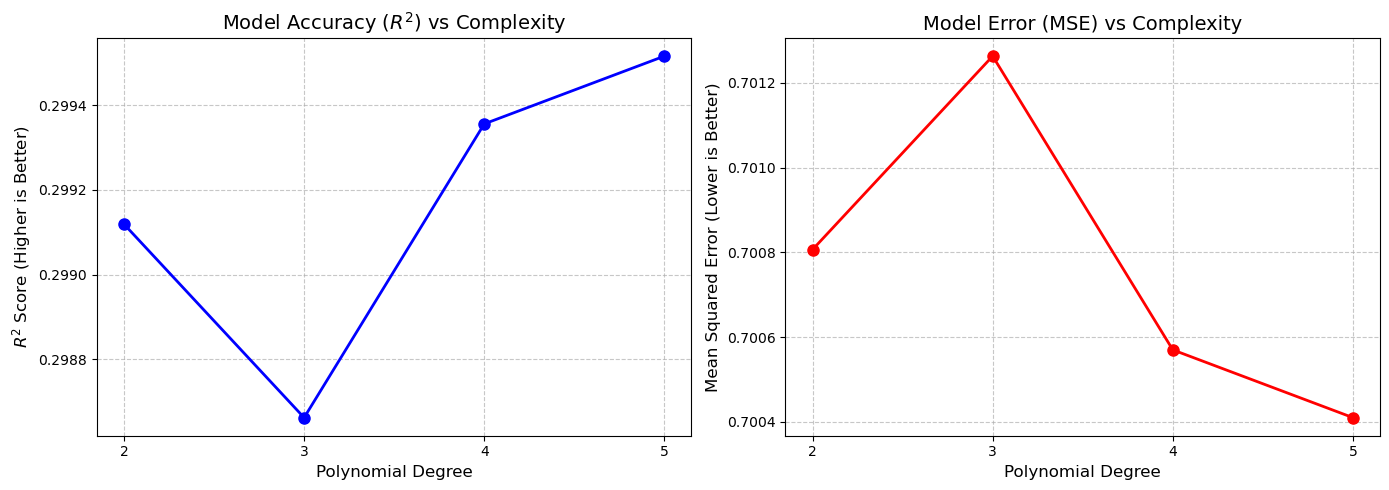

In [166]:
# 1. Create empty lists to save the scores
degrees = list(range(2, 6))
r2_scores = []
mse_scores = []

# 2. Run your exact same loop
for d in degrees:
    multi_model_poly = PolyRegressionScratch(degree=d, learning_rate=lr, n_iterations=n_iter)
    multi_model_poly.fit(X_train_scaled, y_train_reshaped)
    multi_y_pred = multi_model_poly.predict(X_test_scaled)
    
    mse = mean_squared_error(y_test_reshaped, multi_y_pred)
    r2 = r2_score(y_test_reshaped, multi_y_pred)
    
    # Save the metrics
    r2_scores.append(r2)
    mse_scores.append(mse)

# 3. Create a side-by-side plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: R-Squared (Higher is better)
ax1.plot(degrees, r2_scores, marker='o', color='blue', linewidth=2, markersize=8)
ax1.set_title('Model Accuracy ($R^2$) vs Complexity', fontsize=14)
ax1.set_xlabel('Polynomial Degree', fontsize=12)
ax1.set_ylabel('$R^2$ Score (Higher is Better)', fontsize=12)
ax1.set_xticks(degrees)
ax1.grid(True, linestyle='--', alpha=0.7)

# Plot 2: Mean Squared Error (Lower is better)
ax2.plot(degrees, mse_scores, marker='o', color='red', linewidth=2, markersize=8)
ax2.set_title('Model Error (MSE) vs Complexity', fontsize=14)
ax2.set_xlabel('Polynomial Degree', fontsize=12)
ax2.set_ylabel('Mean Squared Error (Lower is Better)', fontsize=12)
ax2.set_xticks(degrees)
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [167]:
from itertools import combinations_with_replacement

class PolyRegressionScratch:

    def __init__(self, degree=2, learning_rate=0.01, n_iterations=1000):
        self.degree = degree
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        
        self.coef_ = None
        self.intercept_ = None
        self.feature_means_ = None
        self.feature_stds_ = None

    def _polynomial_features(self, X):
        # Convert to numpy array just in case a DataFrame is passed in
        X = np.array(X)
        m, n = X.shape
        features = []

        for d in range(1, self.degree + 1):
            for combo in combinations_with_replacement(range(n), d):
                term = np.prod(X[:, list(combo)], axis=1, keepdims=True)
                features.append(term)

        return np.concatenate(features, axis=1)

    def _scale_features(self, X_poly, is_training=False):
        if is_training:
            self.feature_means_ = np.mean(X_poly, axis=0)
            self.feature_stds_ = np.std(X_poly, axis=0)
            # Replace near-zero stds with 1.0 instead of adding 1e-8
            self.feature_stds_[self.feature_stds_ < 1e-8] = 1.0
            
        return (X_poly - self.feature_means_) / self.feature_stds_

    def fit(self, X, y):
        X = np.array(X)  # handle DataFrames
        y = np.array(y)

        if len(y.shape) == 1:
            y = y.reshape(-1, 1)

        X_poly = self._polynomial_features(X)
        X_poly_scaled = self._scale_features(X_poly, is_training=True)
        
        m, n_features = X_poly_scaled.shape
        
        self.coef_ = np.zeros((n_features, 1))
        self.intercept_ = 0.0

        for _ in range(self.n_iterations):
            y_pred = np.dot(X_poly_scaled, self.coef_) + self.intercept_
            residuals = y_pred - y

            intercept_gradient = (2/m) * np.sum(residuals)
            coef_gradient = (2/m) * np.dot(X_poly_scaled.T, residuals)

            self.intercept_ -= self.learning_rate * intercept_gradient
            self.coef_ -= self.learning_rate * coef_gradient

            # Early stop if gradients explode
            if np.any(np.isnan(self.coef_)) or np.any(np.isinf(self.coef_)):
                print(f"Warning: Divergence detected, stopping early at iteration {_}")
                break

    def predict(self, X):
        X = np.array(X)  # handle DataFrames
        X_poly = self._polynomial_features(X)
        X_poly_scaled = self._scale_features(X_poly, is_training=False)
        return np.dot(X_poly_scaled, self.coef_) + self.intercept_

    def R_squared(self, y_true, y_pred):
        SSres = np.sum((y_true - y_pred)**2)
        SStot = np.sum((y_true - np.mean(y_true))**2)
        return 1 - (SSres/SStot)

    def MAE(self, y_true, y_pred):
        n = len(y_true)
        return np.sum(np.abs(y_true - y_pred)) / n

    def MSE(self, y_true, y_pred):
        n = len(y_true)
        return np.sum((y_true - y_pred)**2) / n

In [168]:
for d in range(2, 6):
    multi_model_poly = PolyRegressionScratch(degree=d, learning_rate=lr, n_iterations=n_iter)
    multi_model_poly.fit(X_train, y_train_reshaped)
    
    print(f"Degree {d}")

    y_pred = multi_model_poly.predict(X_test).reshape(-1, 1)  # ← fixed
    
    y_test_real = pt.inverse_transform(
        pd.DataFrame(y_test.values.reshape(-1, 1), columns=['Award'])
    ).ravel()

    y_pred_real = pt.inverse_transform(
        pd.DataFrame(y_pred.reshape(-1, 1), columns=['Award'])
    ).ravel()

    test_median = np.nanmedian(y_test_real)
    pred_median = np.nanmedian(y_pred_real)
        
    y_test_real = np.where(np.isfinite(y_test_real), y_test_real, test_median)
    y_pred_real = np.where(np.isfinite(y_pred_real), y_pred_real, pred_median)

    r2 = r2_score(y_test_reshaped, y_pred)
    r2_real = r2_score(y_test_real, y_pred_real)
    mse_real = mean_squared_error(y_test_real, y_pred_real)
    mae_real = mean_absolute_error(y_test_real, y_pred_real)
    rmse_real = np.sqrt(mse_real)

    print(f'R^2: {r2} | R^2 (real): {r2_real} | RMSE (real): ${rmse_real:,.2f} | MAE (real): ${mae_real:,.2f}\n')

Degree 2
R^2: 0.31077838806829194 | R^2 (real): -1.2441417103982664 | RMSE (real): $1,720,858.34 | MAE (real): $449,886.71

Degree 3
R^2: 0.3150916092908166 | R^2 (real): -3.0477247702000545 | RMSE (real): $2,311,135.82 | MAE (real): $459,531.05

Degree 4
R^2: 0.3169415247369972 | R^2 (real): -0.6447847784095999 | RMSE (real): $1,473,243.46 | MAE (real): $433,823.52

Degree 5
R^2: 0.3213535903344561 | R^2 (real): -49689571.72643267 | RMSE (real): $8,097,530,886.77 | MAE (real): $138,359,642.53



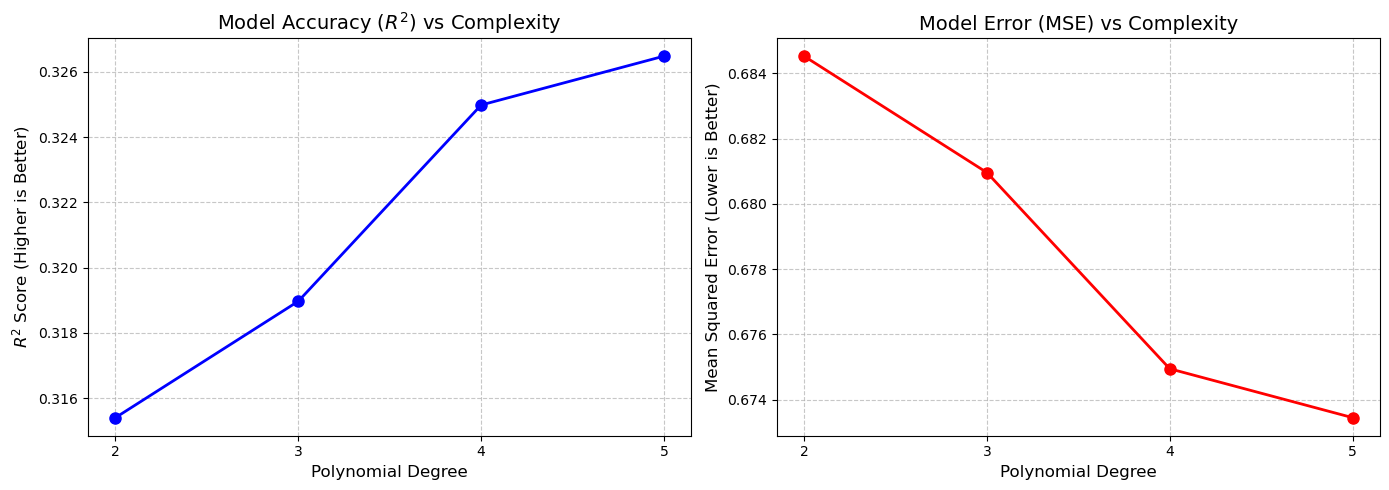

In [169]:
# 1. Create empty lists to save the scores
degrees = list(range(2, 6))
r2_scores = []
mse_scores = []

# 2. Run your exact same loop
for d in degrees:
    multi_model_poly = PolyRegressionScratch(degree=d, learning_rate=lr, n_iterations=n_iter)
    multi_model_poly.fit(X_train_scaled, y_train_reshaped)
    multi_y_pred = multi_model_poly.predict(X_test_scaled)
    
    mse = mean_squared_error(y_test_reshaped, multi_y_pred)
    r2 = r2_score(y_test_reshaped, multi_y_pred)
    
    # Save the metrics
    r2_scores.append(r2)
    mse_scores.append(mse)

# 3. Create a side-by-side plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: R-Squared (Higher is better)
ax1.plot(degrees, r2_scores, marker='o', color='blue', linewidth=2, markersize=8)
ax1.set_title('Model Accuracy ($R^2$) vs Complexity', fontsize=14)
ax1.set_xlabel('Polynomial Degree', fontsize=12)
ax1.set_ylabel('$R^2$ Score (Higher is Better)', fontsize=12)
ax1.set_xticks(degrees)
ax1.grid(True, linestyle='--', alpha=0.7)

# Plot 2: Mean Squared Error (Lower is better)
ax2.plot(degrees, mse_scores, marker='o', color='red', linewidth=2, markersize=8)
ax2.set_title('Model Error (MSE) vs Complexity', fontsize=14)
ax2.set_xlabel('Polynomial Degree', fontsize=12)
ax2.set_ylabel('Mean Squared Error (Lower is Better)', fontsize=12)
ax2.set_xticks(degrees)
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Testing other models

In [170]:
from sklearn.ensemble import GradientBoostingRegressor

# After your existing preprocessing, add log-transformed scores:
for col in ['Year_Score', 'Borough_Score', 'Sector_Score', 'Category_Score']:
    X_train[f'log_{col}'] = np.log(X_train[col])
    X_test[f'log_{col}'] = np.log1p(X_test[col])

model = GradientBoostingRegressor(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    min_samples_leaf=20,
    random_state=42
)


# Train
model.fit(X_train, y_train)

# Predict (log space)
y_pred = model.predict(X_test)

# During evaluation
y_test_real = pt.inverse_transform(
    pd.DataFrame(y_test.values.reshape(-1, 1), columns=['Award'])
).ravel()

y_pred_real = pt.inverse_transform(
    pd.DataFrame(y_pred.reshape(-1, 1), columns=['Award'])
).ravel()

# Compute metrics in real scale
mse_real = mean_squared_error(y_test_real, y_pred_real)
mae_real = mean_absolute_error(y_test_real, y_pred_real)
r2_yj = r2_score(y_test, y_pred)
r2_real = r2_score(y_test_real, y_pred_real)
rmse_real = np.sqrt(mse_real)

print(f'R^2: {r2_yj} | R^2 (real): {r2_real} | RMSE (real): ${rmse_real:,.2f} | MAE (real): ${mae_real:,.2f}\n')



R^2: 0.37899939234263247 | R^2 (real): 0.050062252332960355 | RMSE (real): $1,119,612.03 | MAE (real): $398,211.75



Let's try a GradientBoostingRegressor scratch model from: https://www.kaggle.com/code/egazakharenko/gradient-boosting-from-scratch-full-tutorial/notebook

In [171]:
from sklearn.tree import DecisionTreeRegressor

class GBMRegressor:
    def __init__(self, learning_rate=0.1, n_estimators=100, max_depth=3, random_state=0):
        self.learning_rate = learning_rate
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.random_state = random_state
        self.trees = []

    def fit(self, X, y):
        self.initial_leaf = y.mean()
        predictions = np.zeros(len(y)) + self.initial_leaf

        for _ in range(self.n_estimators):
            residuals = y - predictions
            tree = DecisionTreeRegressor(criterion='friedman_mse', max_depth=self.max_depth,
                                         random_state=self.random_state)
            tree.fit(X, residuals)
            predictions += self.learning_rate * tree.predict(X)
            self.trees.append(tree)

    def predict(self, samples):
        predictions = np.zeros(len(samples)) + self.initial_leaf

        for i in range(self.n_estimators):
            predictions += self.learning_rate * self.trees[i].predict(samples)

        return predictions

In [172]:
model_new = GBMRegressor()
model_new.fit(X_train, y_train)

y_pred = model_new.predict(X_test)

# During evaluation
y_test_real = pt.inverse_transform(
    pd.DataFrame(y_test.values.reshape(-1, 1), columns=['Award'])
).ravel()

y_pred_real = pt.inverse_transform(
    pd.DataFrame(y_pred.reshape(-1, 1), columns=['Award'])
).ravel()

# Compute metrics in real scale
mse_real = mean_squared_error(y_test_real, y_pred_real)
mae_real = mean_absolute_error(y_test_real, y_pred_real)
r2_yj = r2_score(y_test, y_pred)
r2_real = r2_score(y_test_real, y_pred_real)
rmse_real = np.sqrt(mse_real)

print(f'R^2: {r2_yj} | R^2 (real): {r2_real} | RMSE (real): ${rmse_real:,.2f} | MAE (real): ${mae_real:,.2f}\n')

R^2: 0.376764463165698 | R^2 (real): 0.04748524173274249 | RMSE (real): $1,121,129.65 | MAE (real): $398,510.53



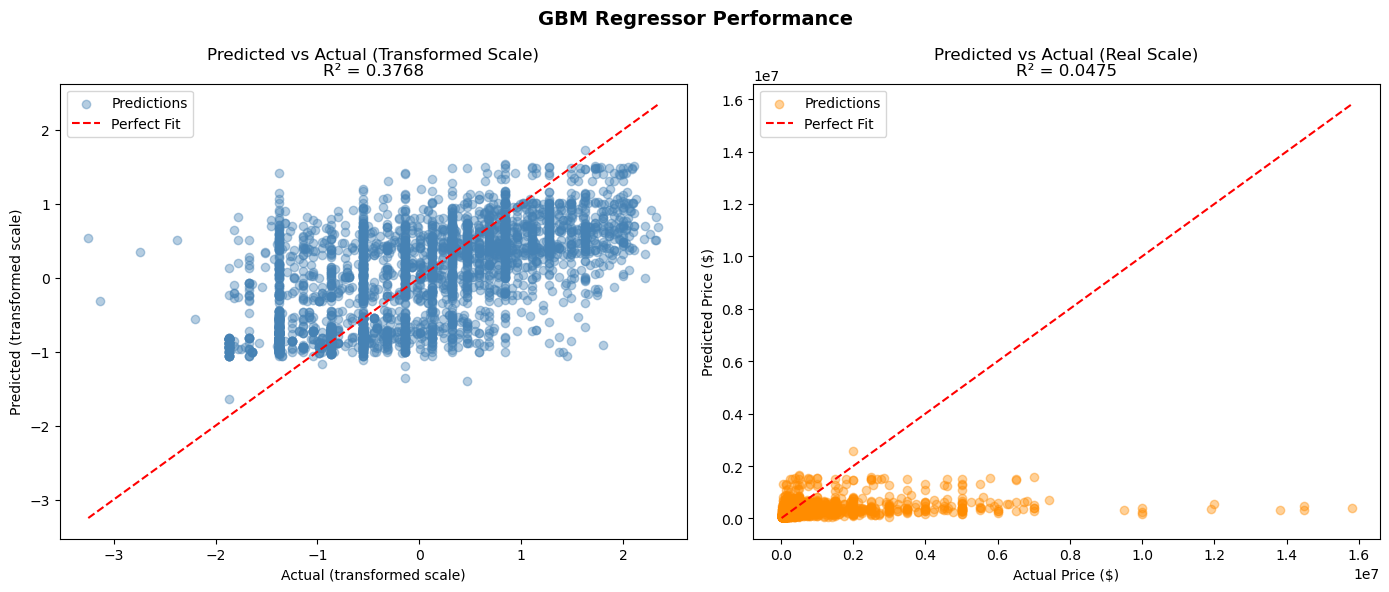

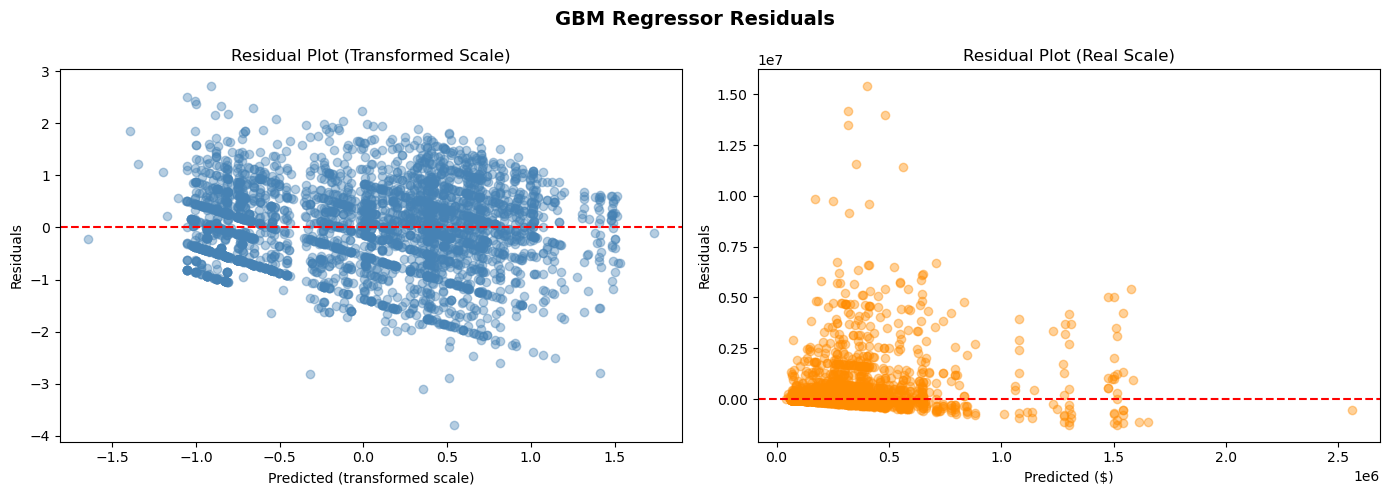

In [173]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Log Scale Plot ---
axes[0].scatter(y_test, y_pred, alpha=0.4, color='steelblue', label='Predictions')
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Fit')
axes[0].set_xlabel('Actual (transformed scale)')
axes[0].set_ylabel('Predicted (transformed scale)')
axes[0].set_title(f'Predicted vs Actual (Transformed Scale)\nR² = {r2_yj:.4f}')
axes[0].legend()

# --- Real Scale Plot ---
axes[1].scatter(y_test_real, y_pred_real, alpha=0.4, color='darkorange', label='Predictions')
min_val = min(y_test_real.min(), y_pred_real.min())
max_val = max(y_test_real.max(), y_pred_real.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Fit')
axes[1].set_xlabel('Actual Price ($)')
axes[1].set_ylabel('Predicted Price ($)')
axes[1].set_title(f'Predicted vs Actual (Real Scale)\nR² = {r2_real:.4f}')
axes[1].legend()

plt.suptitle('GBM Regressor Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Residual Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

residuals_log = y_test - y_pred
residuals_real = y_test_real - y_pred_real

axes[0].scatter(y_pred, residuals_log, alpha=0.4, color='steelblue')
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Predicted (transformed scale)')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residual Plot (Transformed Scale)')

axes[1].scatter(y_pred_real, residuals_real, alpha=0.4, color='darkorange')
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted ($)')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot (Real Scale)')

plt.suptitle('GBM Regressor Residuals', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()